# TDLeaf(λ): learning an evaluation from self-play

Temporal-difference learning asks the evaluation to agree with itself one move
later, and anchors the chain to the game's actual result. Nothing but the rules
is needed — no engine to imitate, no labelled positions.

**TDLeaf, not TD.** The score a search reports belongs to the leaf at the end of
its principal variation, not to the root. Updating the root's features would
train on positions the search never evaluated.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

## The cold-start problem

Learning from all-zero weights sounds purer and does not work. An evaluation
that scores every position at zero plays randomly, random games almost never
finish decisively inside a move limit, and a run of draws carries no gradient.

In [2]:
from research.self_play.value_learner import PieceSquareEvaluator, TDConfig, ValueLearner

cold = ValueLearner(PieceSquareEvaluator(), TDConfig(games=6, depth=2, max_plies=60, time_limit=0.05, seed=1))
cold_result = cold.train()
print("from zero weights")
print("  mean |TD| per game:", [round(e, 4) for e in cold_result.td_errors])
print("  outcomes:", cold_result.outcomes)
print("  -> no signal at all\n")

warm = ValueLearner(PieceSquareEvaluator.material_only(),
                    TDConfig(games=6, depth=2, max_plies=60, time_limit=0.05, seed=1))
warm_result = warm.train()
print("from material-only weights")
print("  mean |TD| per game:", [round(e, 4) for e in warm_result.td_errors])
print("  outcomes:", warm_result.outcomes)

from zero weights
  mean |TD| per game: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  outcomes: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  -> no signal at all

from material-only weights
  mean |TD| per game: [0.0955, 0.0732, 0.043, 0.0906, 0.0574, 0.0545]
  outcomes: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## A longer run

Seeding the material and leaving placement flat sharpens the question to one
self-play can actually answer: *can it rediscover where the pieces belong?*

In [3]:
CENTRE = [chess_sq for chess_sq in (27, 28, 35, 36)]   # d4 e4 d5 e5
RIM = [0, 7, 56, 63]                                    # a1 h1 a8 h8

def centre_minus_rim(evaluator, piece_index):
    weights = evaluator.weights[piece_index * 64:(piece_index + 1) * 64]
    return float(np.mean(weights[CENTRE]) - np.mean(weights[RIM]))

evaluator = PieceSquareEvaluator.material_only()
learner = ValueLearner(evaluator, TDConfig(games=120, depth=2, max_plies=120,
                                           time_limit=0.05, learning_rate=40.0, seed=7))
knight_trace, td_trace = [], []
def track(index, trace, error):
    knight_trace.append(centre_minus_rim(evaluator, 1))
    td_trace.append(error)

result = learner.train(on_game=track)
print(f"{len(result.td_errors)} games in {result.seconds:.0f}s")
print("outcomes: white %d, black %d, draw %d" % (
    result.outcomes.count(1.0), result.outcomes.count(-1.0), result.outcomes.count(0.0)))

120 games in 18s
outcomes: white 27, black 22, draw 71


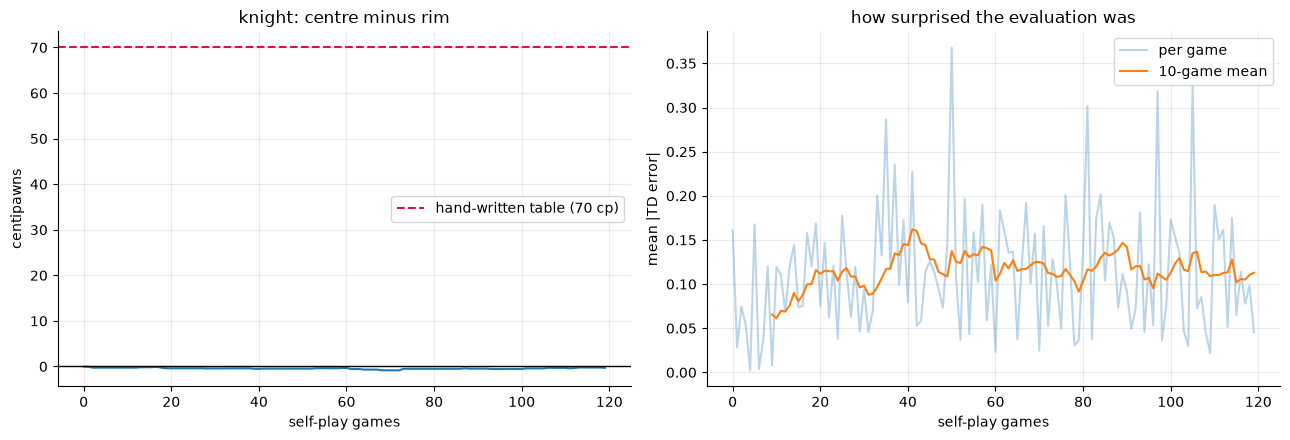

after 120 games: -0.3 cp   target: 70 cp


In [4]:
from engine.evaluation.pst import RAW_MG
import chess as _chess
target = float(np.mean([RAW_MG[_chess.KNIGHT][s ^ 56] for s in CENTRE])
               - np.mean([RAW_MG[_chess.KNIGHT][s ^ 56] for s in RIM]))

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
left.plot(knight_trace)
left.axhline(target, color="crimson", ls="--", label=f"hand-written table ({target:.0f} cp)")
left.axhline(0, color="black", lw=1)
left.set_xlabel("self-play games"); left.set_ylabel("centipawns")
left.set_title("knight: centre minus rim"); left.legend()

window = 10
smoothed = np.convolve(td_trace, np.ones(window) / window, mode="valid")
right.plot(td_trace, alpha=0.3, label="per game")
right.plot(range(window - 1, len(td_trace)), smoothed, label=f"{window}-game mean")
right.set_xlabel("self-play games"); right.set_ylabel("mean |TD error|")
right.set_title("how surprised the evaluation was"); right.legend()
plt.tight_layout(); plt.show()

print(f"after {len(knight_trace)} games: {knight_trace[-1]:+.1f} cp   target: {target:.0f} cp")

## What this shows, and what it does not

The mechanism is sound — the temporal differences are non-zero, the updates
land, the directional unit tests pass. What the left chart shows is that **a
hundred games is two or three orders of magnitude short**. The knight's
centre-minus-rim weight moves by a fraction of a centipawn against a target of
70.

That is not a surprising result and it is worth stating rather than hiding: TD
from self-play is famously sample-hungry, and the games here are played at
depth 2 by an evaluation that is deliberately blind to placement. The useful
output of this notebook is the throughput number below, which says what the
real experiment would cost.

In [5]:
per_game = result.seconds / len(result.td_errors)
for games in (1_000, 10_000, 100_000):
    print(f"{games:>7,} games: {games * per_game / 60:>6.0f} min on one core, "
          f"{games * per_game / 60 / 10:>5.0f} min across ten")

  1,000 games:      3 min on one core,     0 min across ten
 10,000 games:     26 min on one core,     3 min across ten
100,000 games:    255 min on one core,    26 min across ten
